In [1]:
import pandas as pd

df=pd.read_csv("C:/Users/kiran/Videos/KIRAN/MachineLearning/DataSets/household_power_consumption.txt",sep=';',na_values='?',low_memory=False)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [2]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [3]:
(df=='?').sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [4]:
df['datetime']=pd.to_datetime(
    df['Date']+' '+df['Time'],
    dayfirst=True
    )
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   object        
 1   Time                   object        
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   datetime               datetime64[ns]
dtypes: datetime64[ns](1), float64(7), object(2)
memory usage: 158.3+ MB


In [6]:
df['hour']=df['datetime'].dt.hour
df['day']=df['datetime'].dt.day
df['month']=df['datetime'].dt.month
df['weekday']=df['datetime'].dt.dayofweek

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime,hour,day,month,weekday
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,17,16,12,5
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,17,16,12,5
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,17,16,12,5
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,17,16,12,5
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,17,16,12,5


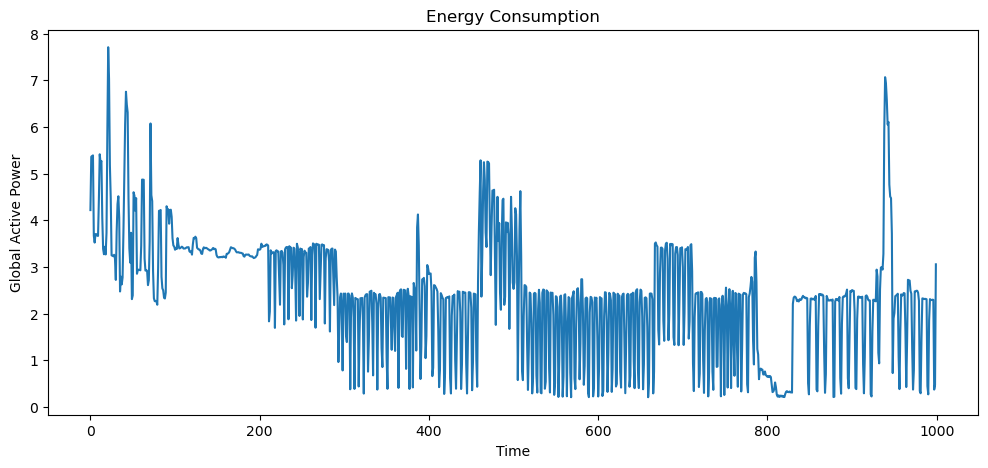

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Global_active_power'].head(1000))
plt.title("Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.show()

In [2]:

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
df_dummy=df.sample(n=50000,random_state=42).dropna()
y=df_dummy['Global_active_power']
x=df_dummy[['hour','day','month','weekday',
        'Voltage',
        'Global_intensity',
        'Sub_metering_1',
        'Sub_metering_2',
        'Sub_metering_3']]

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
model=RandomForestRegressor(n_estimators=50,max_depth=3,random_state=42)
model.fit(X_train,y_train)


NameError: name 'df' is not defined

In [9]:
predicted=model.predict(X_test)
print("R2 SCORE:",r2_score(y_test,predicted))

R2 SCORE: 0.998530615893163


In [10]:
from sklearn.metrics import mean_absolute_error

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2 :", r2_score(y_test, test_pred))

print("MAE:", mean_absolute_error(y_test, test_pred))

Train R2: 0.9985825323540393
Test R2 : 0.998530615893163
MAE: 0.026315063855374677


In [11]:
importance=pd.DataFrame({
    'feature':x.columns,
    'importance':model.feature_importances_
})

importance=importance.sort_values(
    by='importance',
    ascending=False
)
importance

,feature,importance
5,Global_intensity,0.989212
8,Sub_metering_3,0.003851
6,Sub_metering_1,0.002875
2,month,0.001586
4,Voltage,0.001090
0,hour,0.000702
7,Sub_metering_2,0.000586
1,day,0.000100
3,weekday,0.000000


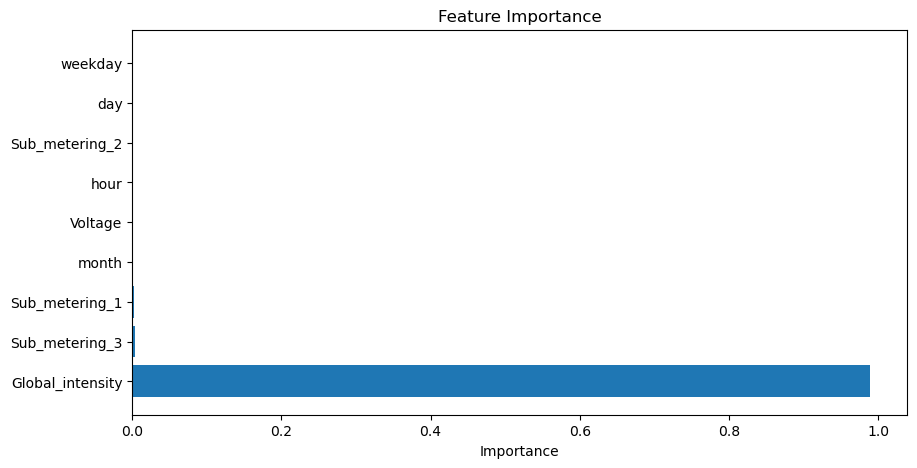

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(importance['feature'],importance['importance'])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

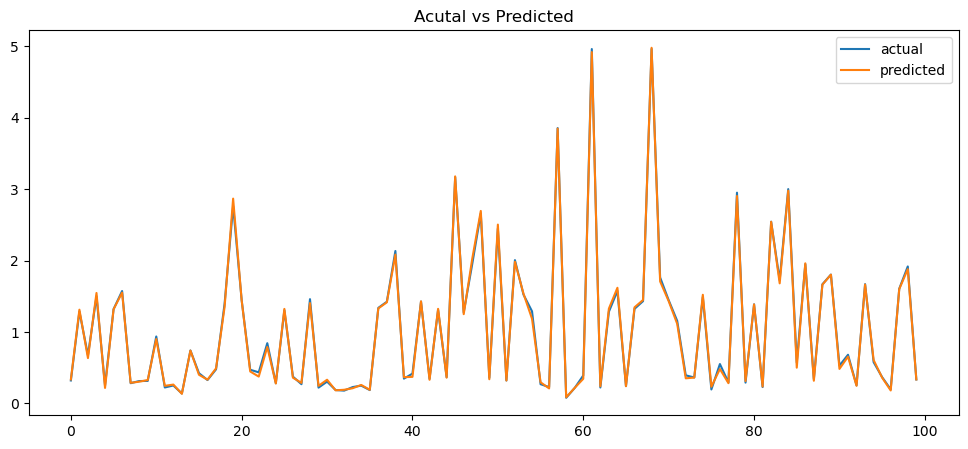

In [13]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:100], label='actual')
plt.plot(test_pred[:100], label='predicted')
plt.title("Acutal vs Predicted")
plt.legend()
plt.show

In [14]:
import joblib
joblib.dump(model,"energy_consumption_model.pkl",compress=3)
print("Model saved succesfully")

Model saved succesfully


In [15]:
loaded_model=joblib.load("energy_consumption_model.pkl")
print("Model Loaded Successfully")

Model Loaded Successfully
